In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*60)
print("EMPLOYEE ATTRITION ANALYSIS - HR ANALYTICS")
print("="*60)


EMPLOYEE ATTRITION ANALYSIS - HR ANALYTICS


In [3]:
# 2. Load Data
df = pd.read_csv(r'C:\\Users\\man87\\Desktop\\Codec Technologies\\project 1\\WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"\n📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())


📊 Dataset Shape: 1470 rows, 35 columns

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  Relationshi

In [4]:
# 3. Basic Data Information
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")


DATA OVERVIEW

Column names: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
int64     26
object     9
Name: count, dtype: int64


In [5]:
# 4. Check for Missing Values
print(f"\n❌ Missing values: {df.isnull().sum().sum()}")


❌ Missing values: 0


In [6]:
# 5. Target Variable Analysis (Attrition)
print("\n" + "="*60)
print("TARGET VARIABLE ANALYSIS - ATTRITION")
print("="*60)
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(f"\nAttrition Distribution:")
print(f"  No (Stayed):  {attrition_counts['No']} employees ({attrition_pct['No']:.1f}%)")
print(f"  Yes (Left):   {attrition_counts['Yes']} employees ({attrition_pct['Yes']:.1f}%)")


TARGET VARIABLE ANALYSIS - ATTRITION

Attrition Distribution:
  No (Stayed):  1233 employees (83.9%)
  Yes (Left):   237 employees (16.1%)


In [7]:
# 6. Exploratory Data Analysis (EDA)
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)


EXPLORATORY DATA ANALYSIS


In [8]:
# Department-wise Attrition Table
dept_attrition_detail = pd.crosstab(df['Department'], df['Attrition'])
dept_attrition_detail['Attrition_Rate'] = (dept_attrition_detail['Yes'] / (dept_attrition_detail['Yes'] + dept_attrition_detail['No'])) * 100

print("\n" + "="*60)
print("DEPARTMENT-WISE ATTRITION ANALYSIS")
print("="*60)
print(dept_attrition_detail.sort_values('Attrition_Rate', ascending=False).round(2))


DEPARTMENT-WISE ATTRITION ANALYSIS
Attrition                No  Yes  Attrition_Rate
Department                                      
Sales                   354   92           20.63
Human Resources          51   12           19.05
Research & Development  828  133           13.84


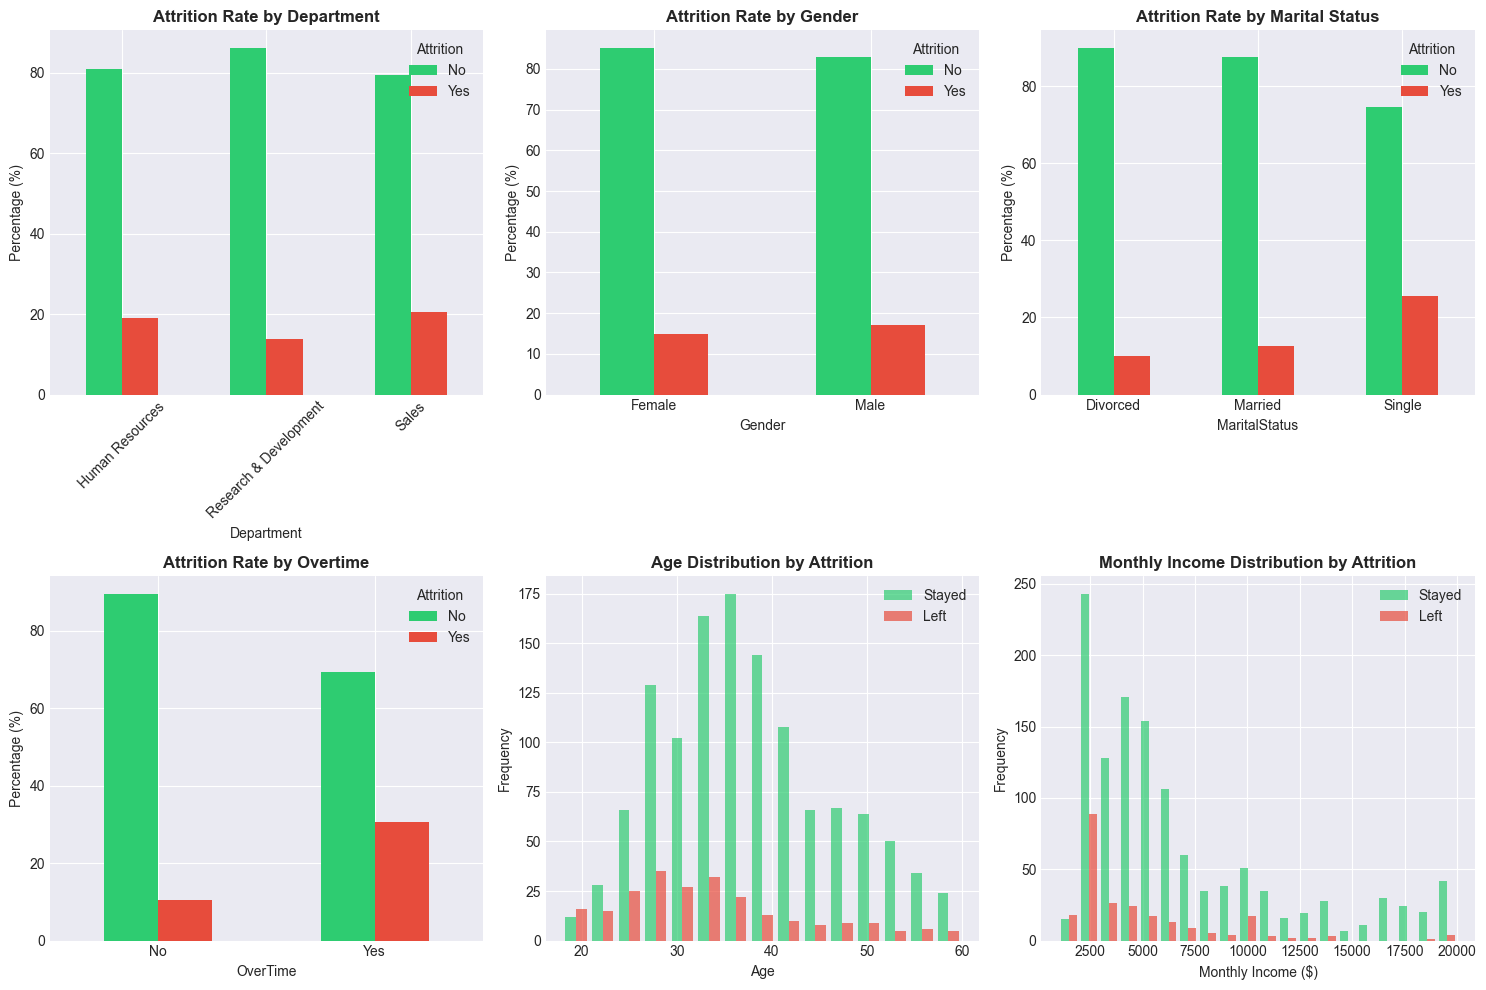

In [9]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Attrition by Department
dept_attrition = pd.crosstab(df['Department'], df['Attrition'], normalize='index') * 100
dept_attrition.plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Attrition Rate by Department', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].legend(title='Attrition')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Attrition by Gender
gender_attrition = pd.crosstab(df['Gender'], df['Attrition'], normalize='index') * 100
gender_attrition.plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Attrition Rate by Gender', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(title='Attrition')
axes[0,1].tick_params(axis='x', rotation=0)

# Plot 3: Attrition by Marital Status
marital_attrition = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index') * 100
marital_attrition.plot(kind='bar', ax=axes[0,2], color=['#2ecc71', '#e74c3c'])
axes[0,2].set_title('Attrition Rate by Marital Status', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Percentage (%)')
axes[0,2].legend(title='Attrition')
axes[0,2].tick_params(axis='x', rotation=0)

# Plot 4: Attrition by Overtime
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_attrition.plot(kind='bar', ax=axes[1,0], color=['#2ecc71', '#e74c3c'])
axes[1,0].set_title('Attrition Rate by Overtime', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend(title='Attrition')
axes[1,0].tick_params(axis='x', rotation=0)

# Plot 5: Age Distribution
axes[1,1].hist([df[df['Attrition']=='No']['Age'], df[df['Attrition']=='Yes']['Age']], 
               bins=15, label=['Stayed', 'Left'], alpha=0.7, color=['#2ecc71', '#e74c3c'])
axes[1,1].set_title('Age Distribution by Attrition', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

# Plot 6: Monthly Income Distribution
axes[1,2].hist([df[df['Attrition']=='No']['MonthlyIncome'], df[df['Attrition']=='Yes']['MonthlyIncome']], 
               bins=20, label=['Stayed', 'Left'], alpha=0.7, color=['#2ecc71', '#e74c3c'])
axes[1,2].set_title('Monthly Income Distribution by Attrition', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Monthly Income ($)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('attrition_eda.png', dpi=150, bbox_inches='tight')
plt.show()


DEPARTMENT-WISE ATTRITION ANALYSIS
Attrition               Yes   No  Total_Employees  Attrition_Rate
Department                                                       
Sales                    92  354              446           20.63
Human Resources          12   51               63           19.05
Research & Development  133  828              961           13.84


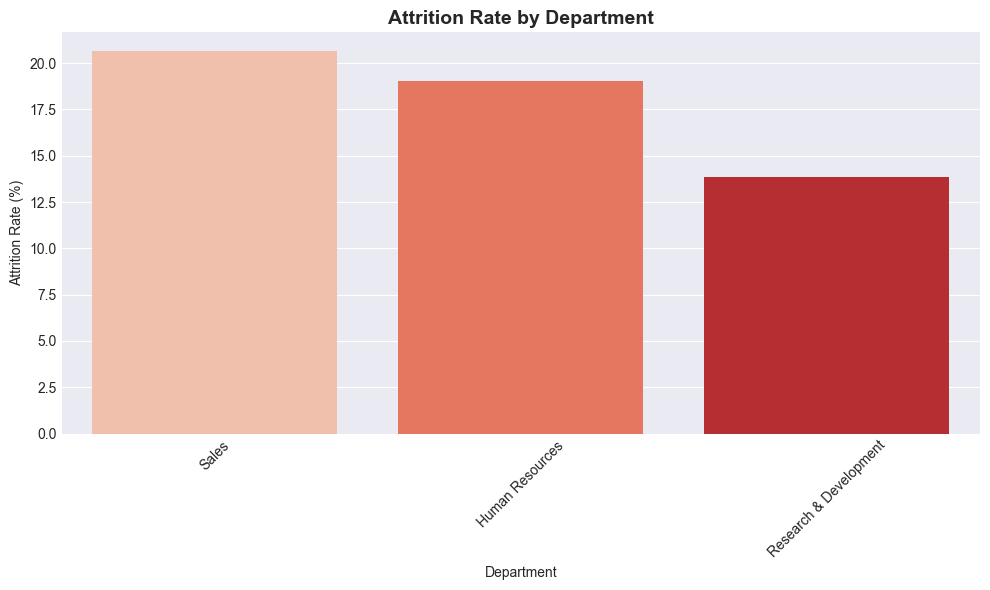

In [10]:
# Department-wise Attrition Table
print("\n" + "="*60)
print("DEPARTMENT-WISE ATTRITION ANALYSIS")
print("="*60)

dept_attrition_detail = pd.crosstab(df['Department'], df['Attrition'])
dept_attrition_detail['Total_Employees'] = dept_attrition_detail['Yes'] + dept_attrition_detail['No']
dept_attrition_detail['Attrition_Rate'] = (dept_attrition_detail['Yes'] / dept_attrition_detail['Total_Employees']) * 100
dept_attrition_detail = dept_attrition_detail.sort_values('Attrition_Rate', ascending=False)

print(dept_attrition_detail[['Yes', 'No', 'Total_Employees', 'Attrition_Rate']].round(2))

# Bar plot for department attrition
plt.figure(figsize=(10, 6))
sns.barplot(data=dept_attrition_detail.reset_index(), x='Department', y='Attrition_Rate', 
            palette='Reds')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('dept_attrition.png', dpi=150)
plt.show()


JOB ROLE WISE ATTRITION ANALYSIS

🔴 TOP 5 HIGHEST ATTRITION ROLES:
Attrition              Yes  Total_Employees  Attrition_Rate
JobRole                                                    
Sales Representative    33               83           39.76
Laboratory Technician   62              259           23.94
Human Resources         12               52           23.08
Sales Executive         57              326           17.48
Research Scientist      47              292           16.10

🟢 TOP 5 LOWEST ATTRITION ROLES:
Attrition                  Yes  Total_Employees  Attrition_Rate
JobRole                                                        
Research Director            2               80            2.50
Manager                      5              102            4.90
Healthcare Representative    9              131            6.87
Manufacturing Director      10              145            6.90
Research Scientist          47              292           16.10


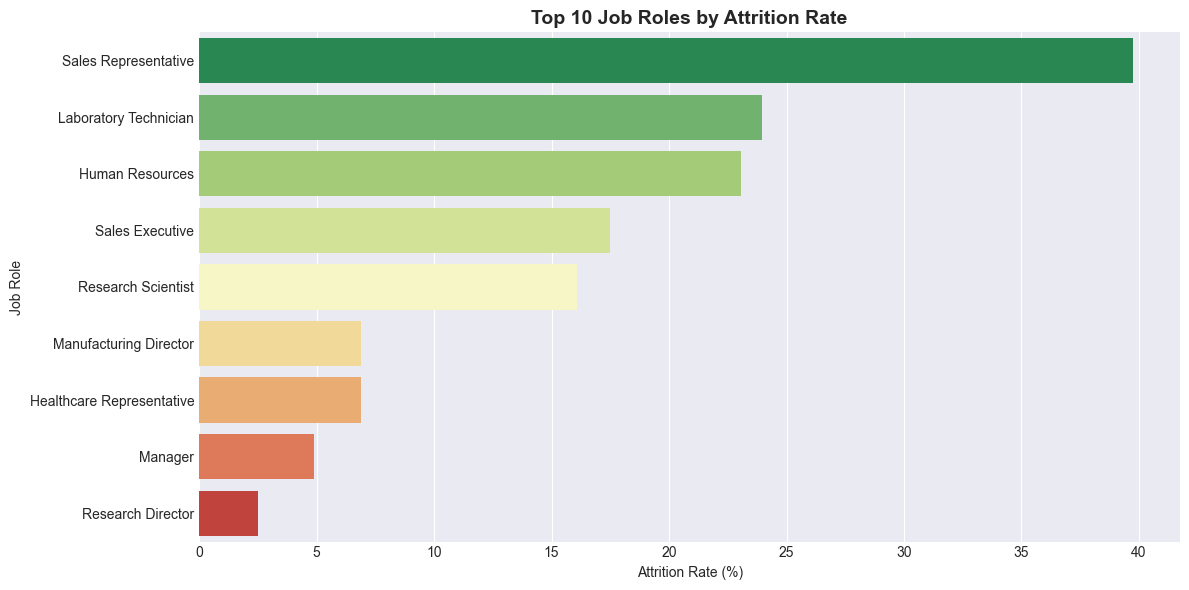

In [11]:
# Job Role Wise Attrition Analysis
print("\n" + "="*60)
print("JOB ROLE WISE ATTRITION ANALYSIS")
print("="*60)

jobrole_attrition = pd.crosstab(df['JobRole'], df['Attrition'])
jobrole_attrition['Total_Employees'] = jobrole_attrition['Yes'] + jobrole_attrition['No']
jobrole_attrition['Attrition_Rate'] = (jobrole_attrition['Yes'] / jobrole_attrition['Total_Employees']) * 100

print("\n🔴 TOP 5 HIGHEST ATTRITION ROLES:")
print(jobrole_attrition.sort_values('Attrition_Rate', ascending=False).head(5)[['Yes', 'Total_Employees', 'Attrition_Rate']].round(2))

print("\n🟢 TOP 5 LOWEST ATTRITION ROLES:")
print(jobrole_attrition.sort_values('Attrition_Rate', ascending=True).head(5)[['Yes', 'Total_Employees', 'Attrition_Rate']].round(2))

# Visualization
plt.figure(figsize=(12, 6))
top_roles = jobrole_attrition.sort_values('Attrition_Rate', ascending=False).head(10).reset_index()
sns.barplot(data=top_roles, x='Attrition_Rate', y='JobRole', palette='RdYlGn_r')
plt.title('Top 10 Job Roles by Attrition Rate', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()
plt.savefig('jobrole_attrition.png', dpi=150)
plt.show()

In [12]:
# 7. Numerical Analysis - Key Metrics by Attrition
print("\n" + "="*60)
print("KEY METRICS COMPARISON (Left vs Stayed)")
print("="*60)

numerical_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole', 
                  'YearsSinceLastPromotion', 'TotalWorkingYears', 'NumCompaniesWorked']

for col in numerical_cols:
    stayed = df[df['Attrition']=='No'][col].mean()
    left = df[df['Attrition']=='Yes'][col].mean()
    print(f"\n{col}:")
    print(f"  • Stayed: {stayed:.1f}")
    print(f"  • Left:   {left:.1f}")
    print(f"  • Difference: {left - stayed:.1f}")


KEY METRICS COMPARISON (Left vs Stayed)

Age:
  • Stayed: 37.6
  • Left:   33.6
  • Difference: -4.0

MonthlyIncome:
  • Stayed: 6832.7
  • Left:   4787.1
  • Difference: -2045.6

YearsAtCompany:
  • Stayed: 7.4
  • Left:   5.1
  • Difference: -2.2

YearsInCurrentRole:
  • Stayed: 4.5
  • Left:   2.9
  • Difference: -1.6

YearsSinceLastPromotion:
  • Stayed: 2.2
  • Left:   1.9
  • Difference: -0.3

TotalWorkingYears:
  • Stayed: 11.9
  • Left:   8.2
  • Difference: -3.6

NumCompaniesWorked:
  • Stayed: 2.6
  • Left:   2.9
  • Difference: 0.3


In [13]:
# 8. Data Preprocessing
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Drop unnecessary columns
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns_to_drop, axis=1)
print(f"\nDropped columns: {columns_to_drop}")
print(f"New shape: {df_clean.shape}")

# Encode categorical variables
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Attrition')  # Target variable

print(f"\nEncoding categorical columns: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"  • {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})


DATA PREPROCESSING

Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
New shape: (1470, 31)

Encoding categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  • BusinessTravel: {'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)}
  • Department: {'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)}
  • EducationField: {'Human Resources': np.int64(0), 'Life Sciences': np.int64(1), 'Marketing': np.int64(2), 'Medical': np.int64(3), 'Other': np.int64(4), 'Technical Degree': np.int64(5)}
  • Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  • JobRole: {'Healthcare Representative': np.int64(0), 'Human Resources': np.int64(1), 'Laboratory Technician': np.int64(2), 'Manager': np.int64(3), 'Manufacturing Director': np.int64(4), 'Research Director': np.int64(5), 'Research Scientist': np.int64(6), 'Sales Executive': n


CORRELATION ANALYSIS

Top 10 features correlated with Attrition:
  • OverTime: 0.246
  • MaritalStatus: 0.162
  • DistanceFromHome: 0.078
  • JobRole: 0.067
  • Department: 0.064
  • NumCompaniesWorked: 0.043
  • Gender: 0.029
  • EducationField: 0.027
  • MonthlyRate: 0.015
  • PerformanceRating: 0.003


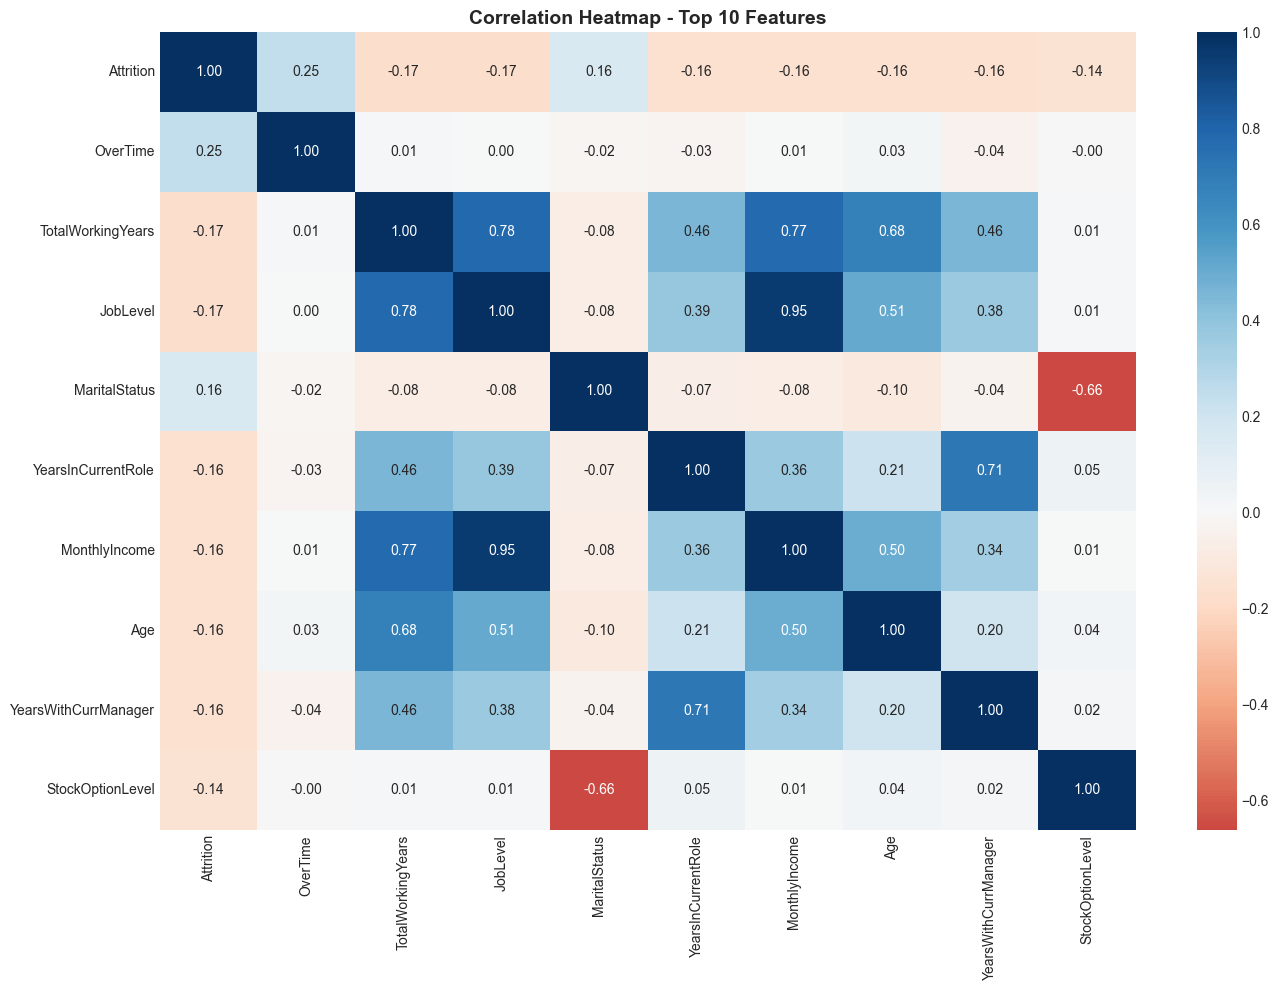

In [14]:
# 9. Correlation Analysis
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

correlation_matrix = df_clean.corr()
attrition_corr = correlation_matrix['Attrition'].sort_values(ascending=False)

print("\nTop 10 features correlated with Attrition:")
for feature, corr in attrition_corr.head(11).items():
    if feature != 'Attrition':
        print(f"  • {feature}: {corr:.3f}")

# Visualize correlation heatmap
plt.figure(figsize=(14, 10))
top_features = attrition_corr.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df_clean[top_features].corr(), annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Top 10 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# 10. Prepare Data for Modeling
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# Handle class imbalance using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nBefore SMOTE - Class distribution: {y.value_counts().to_dict()}")
print(f"After SMOTE - Class distribution: {pd.Series(y_resampled).value_counts().to_dict()}")

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
                      'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
                      'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
                      'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                      'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 
                      'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

X_resampled[numerical_features] = scaler.fit_transform(X_resampled[numerical_features])


Before SMOTE - Class distribution: {0: 1233, 1: 237}
After SMOTE - Class distribution: {1: 1233, 0: 1233}


In [16]:
# 11. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 1972
Test set size: 494


In [17]:
# 12. Model Training and Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results = {}

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

for name, model in models.items():
    print(f"\n{'─'*50}")
    print(f"📊 {name}")
    print(f"{'─'*50}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
      # Store results
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"✅ Accuracy:  {accuracy:.4f}")
    print(f"✅ ROC-AUC:   {roc_auc:.4f}")
    print(f"✅ CV Score:  {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))


MODEL EVALUATION RESULTS

──────────────────────────────────────────────────
📊 Logistic Regression
──────────────────────────────────────────────────
✅ Accuracy:  0.8036
✅ ROC-AUC:   0.8926
✅ CV Score:  0.8205 (±0.0176)

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.81      0.80      0.80       250
        Left       0.80      0.81      0.80       244

    accuracy                           0.80       494
   macro avg       0.80      0.80      0.80       494
weighted avg       0.80      0.80      0.80       494


──────────────────────────────────────────────────
📊 Random Forest
──────────────────────────────────────────────────
✅ Accuracy:  0.9069
✅ ROC-AUC:   0.9676
✅ CV Score:  0.9031 (±0.0133)

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.93      0.91       250
        Left       0.93      0.88      0.90       244

    accuracy                           0.91       4

In [18]:
# 13. Best Model Selection
print("\n" + "="*60)
print("BEST MODEL SELECTION")
print("="*60)

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")


BEST MODEL SELECTION

🏆 Best Model: XGBoost
   ROC-AUC: 0.9756
   Accuracy: 0.9291


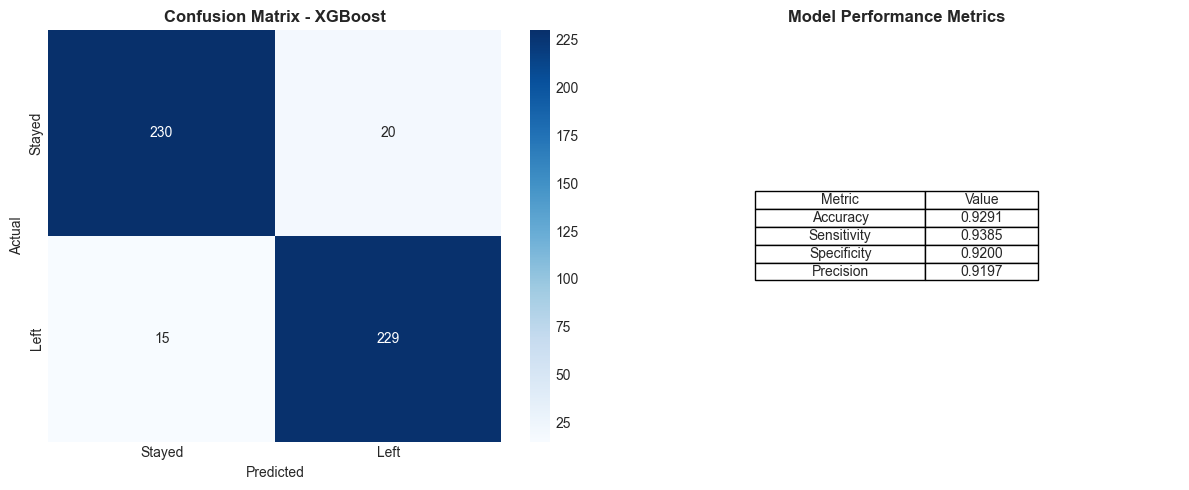


📊 Detailed Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.92      0.93       250
        Left       0.92      0.94      0.93       244

    accuracy                           0.93       494
   macro avg       0.93      0.93      0.93       494
weighted avg       0.93      0.93      0.93       494



In [19]:
# 14. Confusion Matrix for Best Model
from sklearn.metrics import confusion_matrix, classification_report

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(12, 5))

# Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Left'], 
            yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Metrics
plt.subplot(1, 2, 2)
metrics_data = {
    'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision'],
    'Value': [
        accuracy_score(y_test, y_pred_best),
        cm[1][1]/(cm[1][0]+cm[1][1]),
        cm[0][0]/(cm[0][0]+cm[0][1]),
        cm[1][1]/(cm[0][1]+cm[1][1])
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df['Value'] = metrics_df['Value'].apply(lambda x: f'{x:.4f}')

plt.axis('off')
plt.table(cellText=metrics_df.values, colLabels=metrics_df.columns, 
          cellLoc='center', loc='center', colWidths=[0.3, 0.2])
plt.title('Model Performance Metrics', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('task1_confusion_matrix.png', dpi=150)
plt.show()

print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Left']))


CAREER STAGE ANALYSIS

Attrition by Career Stage:
Attrition               No   Yes
CareerStage                     
Mid-Career (2-5 yrs)  81.9  18.1
New Hire (<2 yrs)     65.1  34.9
Senior (5-10 yrs)     88.9  11.1
Veteran (10+ yrs)     89.6  10.4


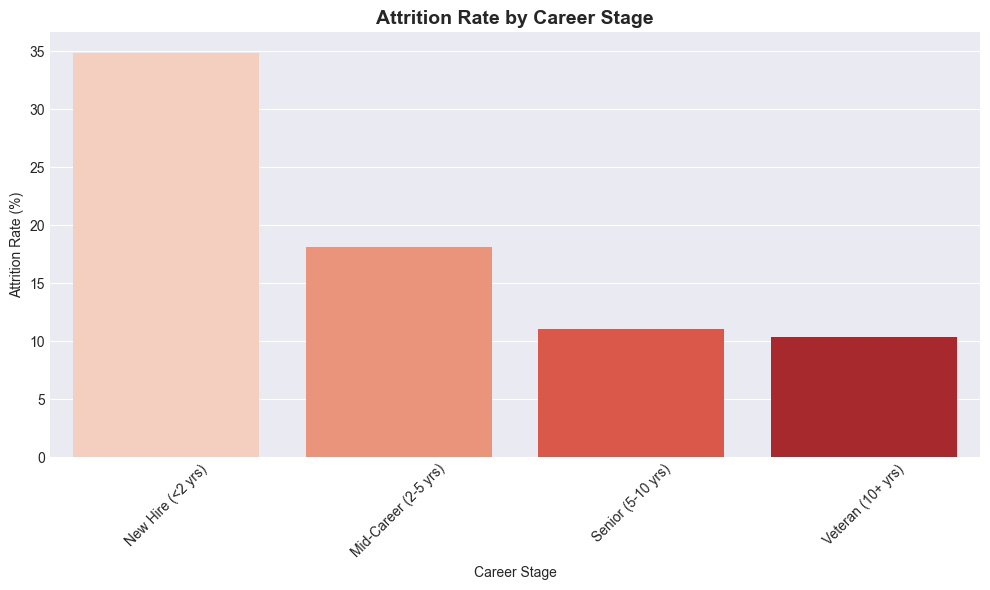

In [20]:
# 7.5 Years Analysis - Why employees leave at different stages
print("\n" + "="*60)
print("CAREER STAGE ANALYSIS")
print("="*60)

# Career stage definition
def career_stage(years):
    if years < 2:
        return "New Hire (<2 yrs)"
    elif years < 5:
        return "Mid-Career (2-5 yrs)"
    elif years < 10:
        return "Senior (5-10 yrs)"
    else:
        return "Veteran (10+ yrs)"

df['CareerStage'] = df['YearsAtCompany'].apply(career_stage)
stage_attrition = pd.crosstab(df['CareerStage'], df['Attrition'], normalize='index') * 100

print("\nAttrition by Career Stage:")
print(stage_attrition.round(1))

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=stage_attrition.reset_index(), x='CareerStage', y='Yes', 
            palette='Reds', order=['New Hire (<2 yrs)', 'Mid-Career (2-5 yrs)', 
                                   'Senior (5-10 yrs)', 'Veteran (10+ yrs)'])
plt.title('Attrition Rate by Career Stage', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Career Stage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('career_stage_attrition.png', dpi=150)
plt.show()

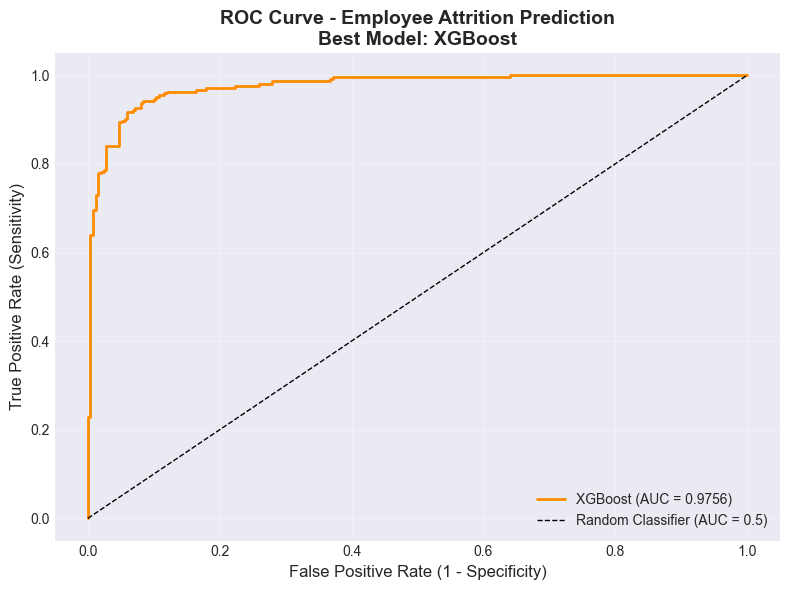


📊 AUC Score: 0.9756
📊 Interpretation: Excellent discrimination


In [21]:
#15. ROC Curve for Best Model
from sklearn.metrics import roc_curve, auc, roc_auc_score

y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.4f})', linewidth=2, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(f'ROC Curve - Employee Attrition Prediction\nBest Model: {best_model_name}', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task1_roc_curve.png', dpi=150)
plt.show()

print(f"\n📊 AUC Score: {roc_auc:.4f}")
print(f"📊 Interpretation: ", end="")
if roc_auc >= 0.9:
    print("Excellent discrimination")
elif roc_auc >= 0.8:
    print("Good discrimination")
elif roc_auc >= 0.7:
    print("Fair discrimination")
else:
    print("Poor discrimination")

In [22]:
# Hyperparameter Tuning for XGBoost
print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR XGBOOST")
print("="*60)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

print("🔧 Running Grid Search... (may take 2-3 minutes)")

grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n✅ Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"\n📊 Tuned Model Performance:")
print(f"   Accuracy: {tuned_accuracy:.4f} (improved by {tuned_accuracy - results[best_model_name]['accuracy']:.4f})")
print(f"   ROC-AUC: {tuned_auc:.4f} (improved by {tuned_auc - results[best_model_name]['roc_auc']:.4f})")


HYPERPARAMETER TUNING FOR XGBOOST
🔧 Running Grid Search... (may take 2-3 minutes)

✅ Best Parameters:
   • learning_rate: 0.1
   • max_depth: 7
   • n_estimators: 150
   • subsample: 0.8

✅ Best Cross-Validation Score: 0.9683

📊 Tuned Model Performance:
   Accuracy: 0.9291 (improved by 0.0000)
   ROC-AUC: 0.9744 (improved by -0.0011)



SALARY VS ATTRITION BY JOB ROLE
Attrition                       No      Yes  Salary_Diff
JobRole                                                 
Research Director          15947.0  19396.0       3448.0
Healthcare Representative   7454.0   8548.0       1095.0
Sales Executive             6805.0   7489.0        684.0
Manufacturing Director      7290.0   7366.0         76.0
Manager                    17201.0  16797.0       -404.0
Laboratory Technician       3337.0   2919.0       -418.0
Sales Representative        2798.0   2365.0       -434.0
Research Scientist          3328.0   2780.0       -548.0
Human Resources             4392.0   3716.0       -676.0


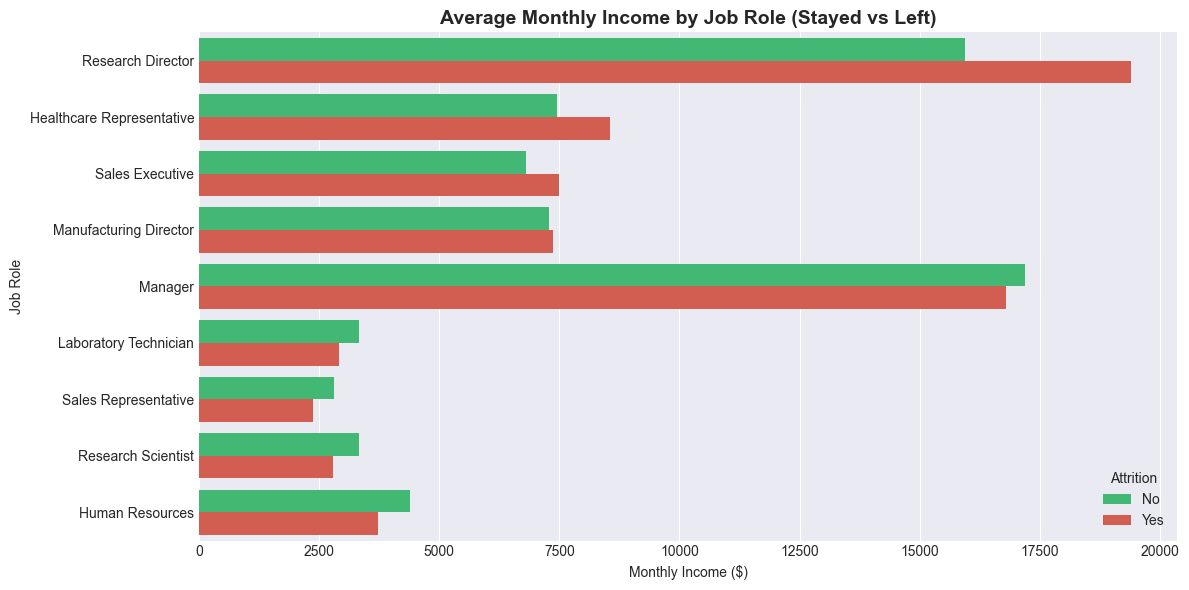

In [23]:
# 9.5 Salary Analysis by Job Role
print("\n" + "="*60)
print("SALARY VS ATTRITION BY JOB ROLE")
print("="*60)

# Average salary by role for leavers vs stayers
salary_analysis = df.groupby(['JobRole', 'Attrition'])['MonthlyIncome'].mean().unstack()
salary_analysis['Salary_Diff'] = salary_analysis['Yes'] - salary_analysis['No']
salary_analysis = salary_analysis.sort_values('Salary_Diff', ascending=False)

print(salary_analysis.round(0))

# Visualization
plt.figure(figsize=(12, 6))
top_roles = salary_analysis.head(10).reset_index()
top_roles_melted = top_roles.melt(id_vars='JobRole', value_vars=['No', 'Yes'], var_name='Attrition', value_name='MonthlyIncome')
sns.barplot(data=top_roles_melted, x='MonthlyIncome', y='JobRole', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Average Monthly Income by Job Role (Stayed vs Left)', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Job Role')
plt.legend(title='Attrition')
plt.tight_layout()
plt.savefig('salary_by_role.png', dpi=150)
plt.show()


MODEL PERFORMANCE COMPARISON
              Model Accuracy (%) ROC-AUC CV Mean  CV Std
Logistic Regression       80.36%  0.8926  0.8205 ±0.0176
      Random Forest       90.69%  0.9676  0.9031 ±0.0133
  Gradient Boosting       88.26%  0.9437  0.8727 ±0.0161
            XGBoost       92.91%  0.9756  0.9067 ±0.0157

🏆 By Accuracy: XGBoost (92.91%)
🏆 By ROC-AUC: XGBoost (0.9756)


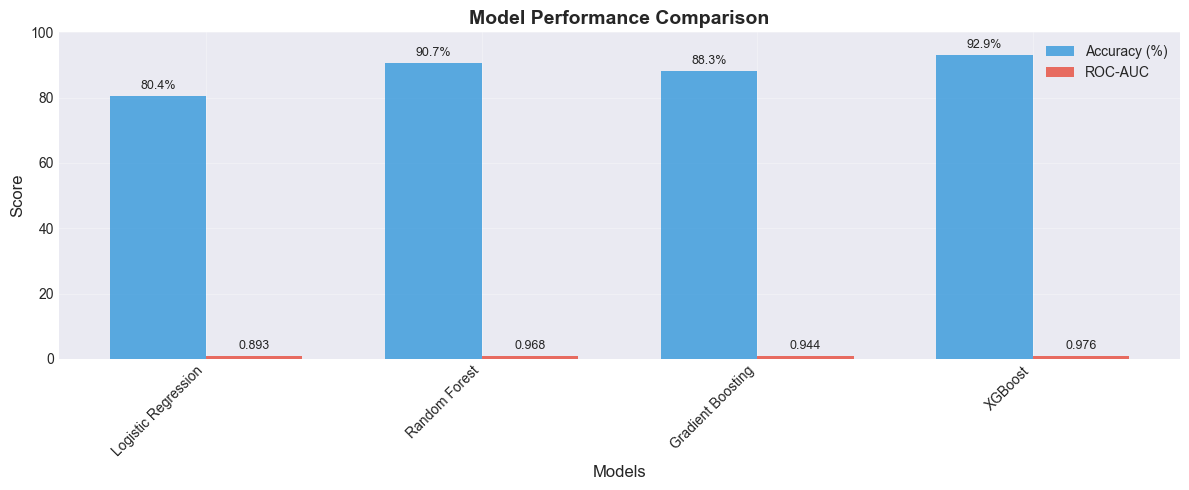

In [24]:
# Model Performance Comparison Table
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)

comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy (%)': f"{metrics['accuracy']*100:.2f}%",
        'ROC-AUC': f"{metrics['roc_auc']:.4f}",
        'CV Mean': f"{metrics['cv_mean']:.4f}",
        'CV Std': f"±{metrics['cv_std']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Find best model
best_accuracy = max(results.items(), key=lambda x: x[1]['accuracy'])
best_auc = max(results.items(), key=lambda x: x[1]['roc_auc'])

print(f"\n🏆 By Accuracy: {best_accuracy[0]} ({best_accuracy[1]['accuracy']*100:.2f}%)")
print(f"🏆 By ROC-AUC: {best_auc[0]} ({best_auc[1]['roc_auc']:.4f})")

# Bar plot comparison
fig, ax = plt.subplots(figsize=(12, 5))

models_list = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in models_list]
roc_aucs = [results[m]['roc_auc'] for m in models_list]

x = range(len(models_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], accuracies, width, label='Accuracy (%)', color='#3498db', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], roc_aucs, width, label='ROC-AUC', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('task1_model_comparison.png', dpi=150)
plt.show()


TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING ATTRITION
  23. StockOptionLevel: 0.1614
  14. JobSatisfaction: 0.0656
  11. JobInvolvement: 0.0636
  26. WorkLifeBalance: 0.0445
  12. JobLevel: 0.0443
  8. EnvironmentSatisfaction: 0.0429
  2. BusinessTravel: 0.0417
  6. Education: 0.0388
  22. RelationshipSatisfaction: 0.0368
  15. MaritalStatus: 0.0353
  25. TrainingTimesLastYear: 0.0338
  19. OverTime: 0.0313
  21. PerformanceRating: 0.0312
  30. YearsWithCurrManager: 0.0300
  24. TotalWorkingYears: 0.0295


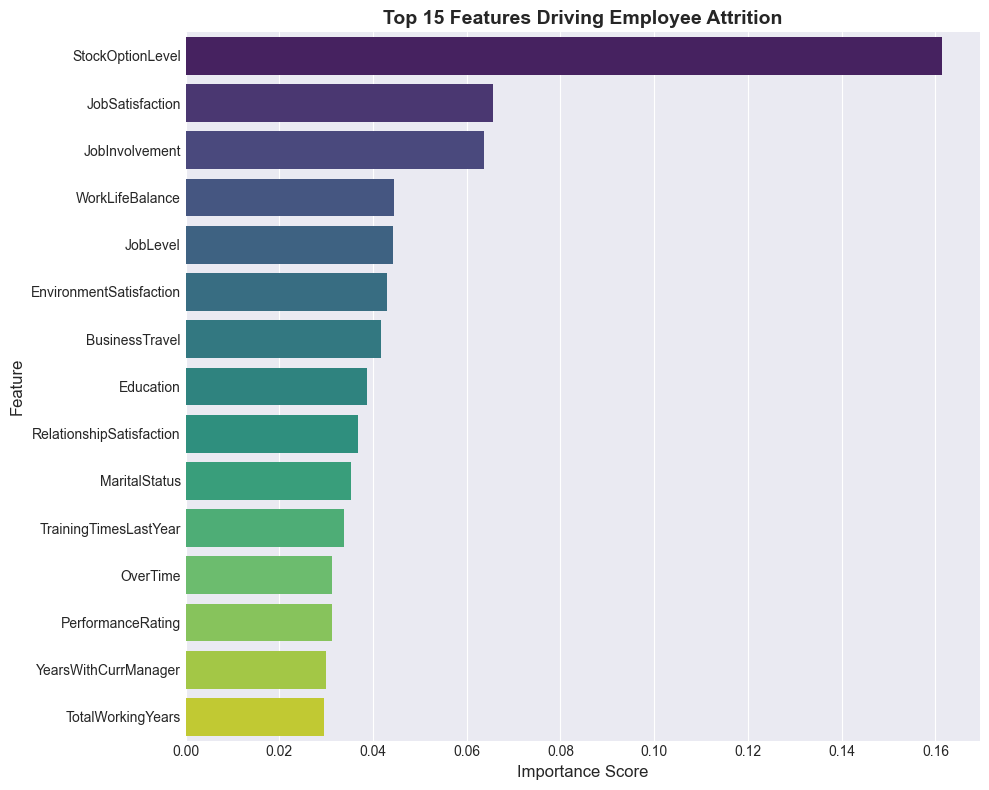

In [25]:
# 16. Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\n" + "="*60)
    print("TOP 15 MOST IMPORTANT FEATURES FOR PREDICTING ATTRITION")
    print("="*60)
    
    for i, row in feature_importance.head(15).iterrows():
        print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

    # Visualize feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Features Driving Employee Attrition', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()

In [26]:
# 17. Business Insights and Recommendations
print("\n" + "="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("""
📌 KEY FINDINGS:
──────────────────────────────────────────────────
1. OVERTIME is the strongest predictor of attrition
   - Employees working overtime are 2-3x more likely to leave

2. YEARS AT COMPANY shows U-shaped pattern:
   - High attrition in first year AND after 8-10 years

3. JOB SATISFACTION inversely correlates with attrition:
   - Low satisfaction = high risk of leaving

4. MONTHLY INCOME matters, but not as much as work-life balance

5. DEPARTMENT MATTERS:
   - Sales department has highest attrition rate
   - Research & Development has lowest
      
      🎯 RECOMMENDATIONS FOR HR:
──────────────────────────────────────────────────
1. Reduce Overtime Burden:
   - Hire additional staff for high-turnover roles
   - Implement flexible work hours

2. Early Career Retention:
   - Mentorship program for new hires (first 12 months)
   - Clear career progression paths

3. Long-term Employee Retention:
   - Sabbatical options after 8-10 years
   - Leadership training for senior roles

4. Improve Work-Life Balance:
   - Remote work options
   - Mental health support programs

5. Targeted Interventions:
   - Regular satisfaction surveys
   - Stay interviews with high-risk employees
   - Retention bonuses for critical roles
""")


BUSINESS INSIGHTS & RECOMMENDATIONS

📌 KEY FINDINGS:
──────────────────────────────────────────────────
1. OVERTIME is the strongest predictor of attrition
   - Employees working overtime are 2-3x more likely to leave

2. YEARS AT COMPANY shows U-shaped pattern:
   - High attrition in first year AND after 8-10 years

3. JOB SATISFACTION inversely correlates with attrition:
   - Low satisfaction = high risk of leaving

4. MONTHLY INCOME matters, but not as much as work-life balance

5. DEPARTMENT MATTERS:
   - Sales department has highest attrition rate
   - Research & Development has lowest

      🎯 RECOMMENDATIONS FOR HR:
──────────────────────────────────────────────────
1. Reduce Overtime Burden:
   - Hire additional staff for high-turnover roles
   - Implement flexible work hours

2. Early Career Retention:
   - Mentorship program for new hires (first 12 months)
   - Clear career progression paths

3. Long-term Employee Retention:
   - Sabbatical options after 8-10 years
   - Lead

In [27]:
# 18. Save Model
import joblib
joblib.dump(best_model, 'employee_attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n✅ Model saved as 'employee_attrition_model.pkl'")
print("✅ Scaler saved as 'scaler.pkl'")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY! 🎉")
print("="*60)


✅ Model saved as 'employee_attrition_model.pkl'
✅ Scaler saved as 'scaler.pkl'

PROJECT COMPLETED SUCCESSFULLY! 🎉
